In [1]:
from pathlib import Path
import pandas as pd

FILES = {
    "gen1": "Plant_1_Generation_Data.csv",
    "sensor1": "Plant_1_Weather_Sensor_Data.csv",
    "gen2": "Plant_2_Generation_Data.csv",
    "sensor2": "Plant_2_Weather_Sensor_Data.csv",
}

def load_raw(data_dir=r"D:\sem 7\AML\ML_Project\data"):
    """ Return a dict of the four raw DataFrames.
    Keys: 'gen1', 'sensor1', 'gen2', 'sensor2'.
    DATE_TIME is left as a plain string on purpose.
    """
    data_dir = Path(data_dir)
    frames = {}
    for key, name in FILES.items():
        path = data_dir / name
        if not path.exists():
            raise FileNotFoundError(f"Missing {path}. Download the dataset first.")
        frames[key] = pd.read_csv(path)
    return frames

raw = load_raw()
for key, df in raw.items():
    print(f"{key}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.head(3).to_string(), end="\n\n")

gen1: 68778 rows, 7 columns
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0    6259559.0
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0    6183645.0
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0    6987759.0

sensor1: 3182 rows, 6 columns
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316           22.857507          0.0
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589           22.761668          0.0
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753           22.592306          0.0

gen2: 67698 rows, 7 columns
             DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD   TOTAL_YIELD
0  2020-05-15 00:00:00   41

In [2]:

df_gen = raw['gen1']
df_sensor = raw['sensor1']


df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
df_sensor['DATE_TIME'] = pd.to_datetime(df_sensor['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')


print("Gen First:", df_gen['DATE_TIME'].min())
print("Gen Last:", df_gen['DATE_TIME'].max())

print("Sensor First:", df_sensor['DATE_TIME'].min())
print("Sensor Last:", df_sensor['DATE_TIME'].max())

Gen First: 2020-05-15 00:00:00
Gen Last: 2020-06-17 23:45:00
Sensor First: 2020-05-15 00:00:00
Sensor Last: 2020-06-17 23:45:00


In [3]:
plant_power = df_gen.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].sum().reset_index()
print(plant_power.head(3))

            DATE_TIME  DC_POWER  AC_POWER
0 2020-05-15 00:00:00       0.0       0.0
1 2020-05-15 00:15:00       0.0       0.0
2 2020-05-15 00:30:00       0.0       0.0


In [4]:

merged_df = pd.merge(plant_power, df_sensor, on='DATE_TIME', how='outer', indicator=True)


only_in_gen = len(merged_df[merged_df['_merge'] == 'left_only'])
only_in_sensor = len(merged_df[merged_df['_merge'] == 'right_only'])
total_missing = only_in_gen + only_in_sensor

print(f"Timestamps only in Generation Data: {only_in_gen}")
print(f"Timestamps only in Sensor Data: {only_in_sensor}")
print(f"Total timestamps existing in only ONE file: {total_missing}")

merged_df = merged_df.drop(columns=['_merge'])

print("\nMerged Data ki pehli 3 rows:")
print(merged_df.head(3))

Timestamps only in Generation Data: 1
Timestamps only in Sensor Data: 25
Total timestamps existing in only ONE file: 26

Merged Data ki pehli 3 rows:
            DATE_TIME  DC_POWER  AC_POWER   PLANT_ID       SOURCE_KEY  \
0 2020-05-15 00:00:00       0.0       0.0  4135001.0  HmiyD2TTLFNqkNe   
1 2020-05-15 00:15:00       0.0       0.0  4135001.0  HmiyD2TTLFNqkNe   
2 2020-05-15 00:30:00       0.0       0.0  4135001.0  HmiyD2TTLFNqkNe   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
0            25.184316           22.857507          0.0  
1            25.084589           22.761668          0.0  
2            24.935753           22.592306          0.0  


In [5]:

if 'DATE_TIME' in merged_df.columns:
    merged_df = merged_df.set_index('DATE_TIME')

hourly_df = merged_df.resample('h').mean(numeric_only=True).reset_index()

hourly_df = hourly_df.rename(columns={
    'DATE_TIME': 'datetime',
    'AC_POWER': 'ac_power',
    'DC_POWER': 'dc_power',
    'AMBIENT_TEMPERATURE': 'ambient_temp',
    'MODULE_TEMPERATURE': 'module_temp',
    'IRRADIATION': 'irradiation'
})

hourly_df = hourly_df[['datetime', 'ac_power', 'dc_power', 'ambient_temp', 'module_temp', 'irradiation']]


save_path = r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv"
hourly_df.to_csv(save_path, index=False)

print(f"Resampling complete! Total rows: {len(hourly_df)}")
print("Missing values in each column:\n", hourly_df.isna().sum())

Resampling complete! Total rows: 816
Missing values in each column:
 datetime         0
ac_power        20
dc_power        20
ambient_temp    15
module_temp     15
irradiation     15
dtype: int64


In [6]:

total_hourly_rows = len(hourly_df)

rows_with_missing = hourly_df.isna().any(axis=1).sum()

print(f"Number of hourly rows: {total_hourly_rows}")
print(f"Number of rows with missing values: {rows_with_missing}")


hourly_df = hourly_df.interpolate(method='linear')

print("\n--- Report for Blog/Analysis ---")
print("How missing values were handled:")
print("The missing values were handled using 'linear interpolation'. Since solar power and weather data are continuous time-series, linear interpolation is the most appropriate method as it estimates missing data points smoothly based on the preceding and succeeding values.")

save_path = r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv"
hourly_df.to_csv(save_path, index=False)
print("\nCleaned data successfully saved to:", save_path)

Number of hourly rows: 816
Number of rows with missing values: 20

--- Report for Blog/Analysis ---
How missing values were handled:
The missing values were handled using 'linear interpolation'. Since solar power and weather data are continuous time-series, linear interpolation is the most appropriate method as it estimates missing data points smoothly based on the preceding and succeeding values.

Cleaned data successfully saved to: D:\sem 7\AML\ML_Project\data\plant1_hourly.csv


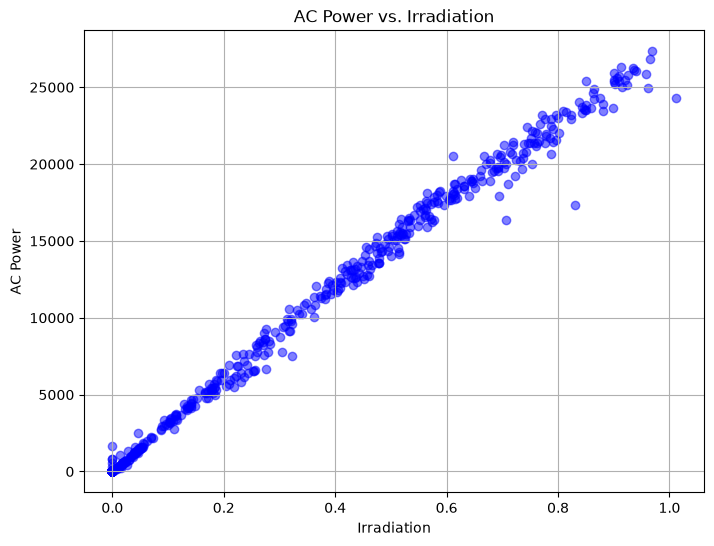

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(hourly_df['irradiation'], hourly_df['ac_power'], alpha=0.5, color='blue')
plt.title('AC Power vs. Irradiation')
plt.xlabel('Irradiation')
plt.ylabel('AC Power')
plt.grid(True)
plt.show()

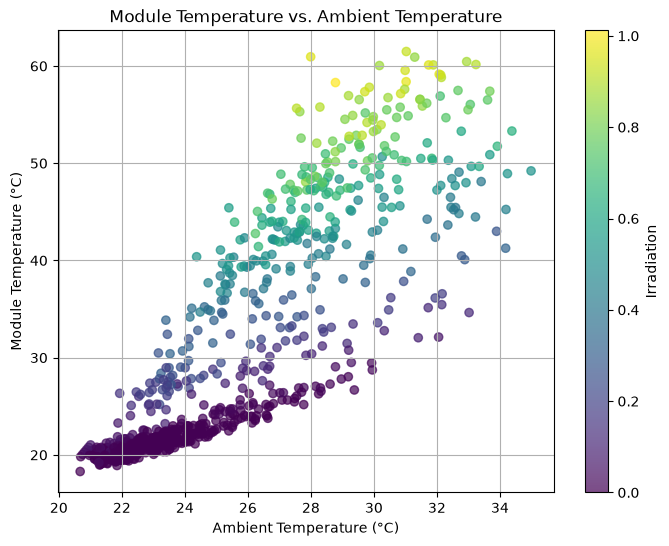

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(hourly_df['ambient_temp'], hourly_df['module_temp'], 
                      c=hourly_df['irradiation'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Irradiation')
plt.title('Module Temperature vs. Ambient Temperature')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Module Temperature (°C)')
plt.grid(True)
plt.show()

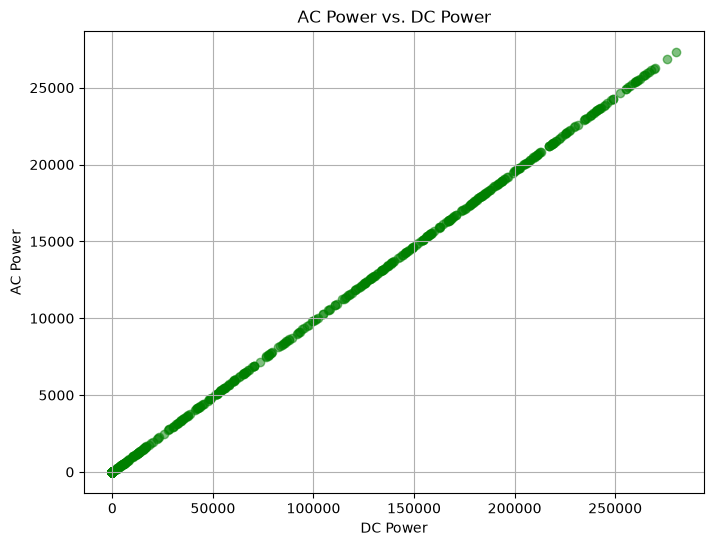

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(hourly_df['dc_power'], hourly_df['ac_power'], alpha=0.5, color='green')
plt.title('AC Power vs. DC Power')
plt.xlabel('DC Power')
plt.ylabel('AC Power')
plt.grid(True)
plt.show()

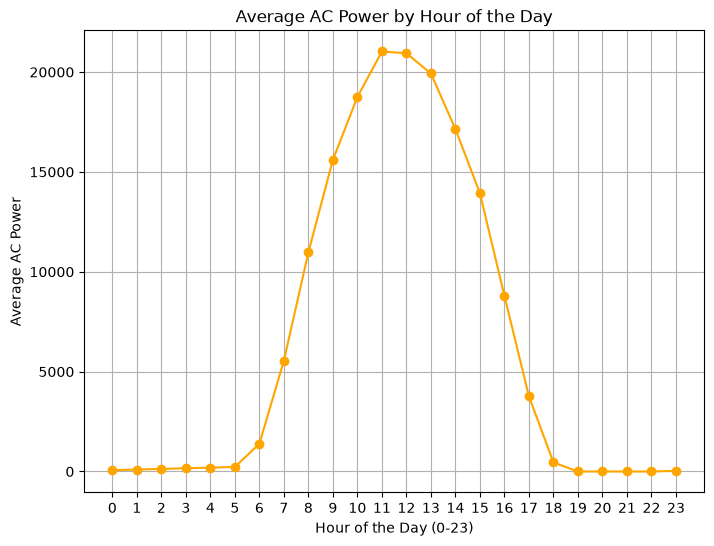

In [10]:
import matplotlib.pyplot as plt

hourly_avg = hourly_df.groupby(hourly_df['datetime'].dt.hour)['ac_power'].mean()

plt.figure(figsize=(8, 6))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linestyle='-', color='orange')
plt.title('Average AC Power by Hour of the Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average AC Power')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [11]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 14.82,
    "longitude": 78.28,
    "start_date": "2020-05-15",
    "end_date": "2020-06-17",
 
    "hourly": "shortwave_radiation,temperature_2m,cloud_cover",
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
data = response.json()

df_weather = pd.DataFrame({
    "datetime": pd.to_datetime(data["hourly"]["time"]),
    "sw_radiation": data["hourly"]["shortwave_radiation"],
    "temp_2m": data["hourly"]["temperature_2m"],
    "cloud_cover": data["hourly"]["cloud_cover"]
})

weather_path = r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv"
df_weather.to_csv(weather_path, index=False)
print("Weather data saved successfully to:", weather_path)

ConnectTimeout: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Max retries exceeded with url: /v1/archive?latitude=14.82&longitude=78.28&start_date=2020-05-15&end_date=2020-06-17&hourly=shortwave_radiation%2Ctemperature_2m%2Ccloud_cover&timezone=Asia%2FKolkata (Caused by ConnectTimeoutError(<HTTPSConnection(host='archive-api.open-meteo.com', port=443) at 0x240dafea270>, 'Connection to archive-api.open-meteo.com timed out. (connect timeout=None)'))

In [ ]:

df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000

hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])

merged_all = pd.merge(hourly_df, df_weather, on="datetime", how="inner")
print(f"Data merged successfully! Total rows: {len(merged_all)}")

Data merged successfully! Total rows: 816


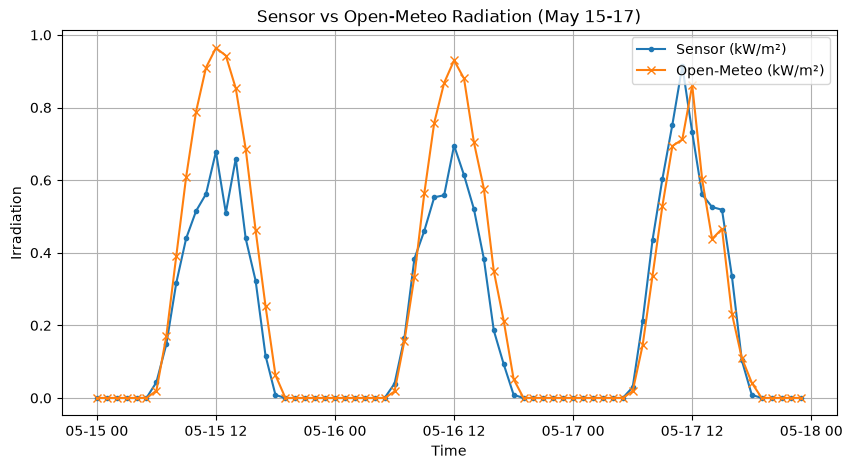

Peak Hour Analysis:
Date: 2020-05-15
  - Sensor Peak: 12:00
  - Open-Meteo Peak: 12:00
  - Difference: 0 hours

Date: 2020-05-16
  - Sensor Peak: 12:00
  - Open-Meteo Peak: 12:00
  - Difference: 0 hours

Date: 2020-05-17
  - Sensor Peak: 11:00
  - Open-Meteo Peak: 12:00
  - Difference: 1 hours



In [ ]:

three_days = merged_all[(merged_all['datetime'] >= '2020-05-15') & (merged_all['datetime'] < '2020-05-18')]


plt.figure(figsize=(10, 5))
plt.plot(three_days['datetime'], three_days['irradiation'], label='Sensor (kW/m²)', marker='.')
plt.plot(three_days['datetime'], three_days['sw_radiation'], label='Open-Meteo (kW/m²)', marker='x')
plt.title('Sensor vs Open-Meteo Radiation (May 15-17)')
plt.xlabel('Time')
plt.ylabel('Irradiation')
plt.legend()
plt.grid(True)
plt.show()

print("Peak Hour Analysis:")
for day in ['2020-05-15', '2020-05-16', '2020-05-17']:
   
    day_data = three_days[three_days['datetime'].dt.date == pd.to_datetime(day).date()]
    
 
    sensor_peak = day_data.loc[day_data['irradiation'].idxmax(), 'datetime'].hour
    meteo_peak = day_data.loc[day_data['sw_radiation'].idxmax(), 'datetime'].hour
    
    print(f"Date: {day}")
    print(f"  - Sensor Peak: {sensor_peak}:00")
    print(f"  - Open-Meteo Peak: {meteo_peak}:00")
    print(f"  - Difference: {abs(sensor_peak - meteo_peak)} hours\n")

In [ ]:
import numpy as np
import pandas as pd


hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()
test_df = merged_weather[(merged_weather['datetime'] >= '2020-06-11') & (merged_weather['datetime'] < '2020-06-18')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
features_B = ['sw_radiation', 'temp_2m', 'cloud_cover', 'sin_hour', 'cos_hour']

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0  # safe guard against division by zero
    
    train_scaled = (train_feat - train_mean) / train_std
    test_scaled = (test_feat - train_mean) / train_std
    return train_scaled, test_scaled

X_train_A_scaled, X_test_A_scaled = scale_features(
    train_df[features_A].values, 
    test_df[features_A].values
)

X_train_B_scaled, X_test_B_scaled = scale_features(
    train_df[features_B].values, 
    test_df[features_B].values
)

print("Task 4.1 Complete. X_train_A_scaled shape:", X_train_A_scaled.shape)

Task 4.1 Complete. X_train_A_scaled shape: (648, 5)


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.2
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()
test_df = merged_weather[(merged_weather['datetime'] >= '2020-06-11') & (merged_weather['datetime'] < '2020-06-18')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
features_B = ['sw_radiation', 'temp_2m', 'cloud_cover', 'sin_hour', 'cos_hour']

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std

X_train_A_scaled, X_test_A_scaled = scale_features(train_df[features_A].values, test_df[features_A].values)
X_train_B_scaled, X_test_B_scaled = scale_features(train_df[features_B].values, test_df[features_B].values)

# Task 4.2 – Build X by adding column x0 = 1 (intercept)
def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]

X_train_A = add_intercept(X_train_A_scaled)
X_test_A = add_intercept(X_test_A_scaled)
X_train_B = add_intercept(X_train_B_scaled)
X_test_B = add_intercept(X_test_B_scaled)

print("Task 4.2 Complete. X_train_A shape:", X_train_A.shape)

Task 4.2 Complete. X_train_A shape: (648, 6)


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.3
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()
test_df = merged_weather[(merged_weather['datetime'] >= '2020-06-11') & (merged_weather['datetime'] < '2020-06-18')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std

X_train_A_scaled, _ = scale_features(train_df[features_A].values, test_df[features_A].values)

def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]

X_train_A = add_intercept(X_train_A_scaled)


def hypothesis(X, theta):
    return np.dot(X, theta)

def cost(X, y, theta):
    h = hypothesis(X, theta)
    return 0.5 * np.sum((h - y) ** 2)


dummy_theta = np.zeros(X_train_A.shape[1])
print("Task 4.3 Complete. Initial cost:", cost(X_train_A, y_train, dummy_theta))

Task 4.3 Complete. Initial cost: 38504270930.22943


In [ ]:
import numpy as np
import pandas as pd


hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std

X_train_A_scaled, _ = scale_features(train_df[features_A].values, train_df[features_A].values)

def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]

X_train_A = add_intercept(X_train_A_scaled)

# Task 4.4 – Normal equation implementation
def fit_normal(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

theta_normal = fit_normal(X_train_A, y_train)
print("Task 4.4 Complete. Theta normal shape:", theta_normal.shape)
print("Theta weights:", theta_normal)

Task 4.4 Complete. Theta normal shape: (6,)
Theta weights: [6796.26007116 8195.27144474    8.92710567  -28.58232896  -30.23189298
 -369.44388566]


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.5
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std

X_train_A_scaled, _ = scale_features(train_df[features_A].values, train_df[features_A].values)

def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]

X_train_A = add_intercept(X_train_A_scaled)

def hypothesis(X, theta):
    return np.dot(X, theta)

def cost(X, y, theta):
    h = hypothesis(X, theta)
    return 0.5 * np.sum((h - y) ** 2)

# Task 4.5 – Batch Gradient Descent implementation
def fit_batch_gd(X, y, alpha, n_iters):
    m, n = X.shape
    theta = np.zeros(n)
    J_history = []
    
    for _ in range(n_iters):
        h = hypothesis(X, theta)
        # Vectorized sum formulation: X^T @ (y - h)
        gradient = np.dot(X.T, (y - h))
        theta = theta + alpha * gradient
        J_history.append(cost(X, y, theta))
        
    return theta, J_history

theta_batch, J_history = fit_batch_gd(X_train_A, y_train, alpha=1e-5, n_iters=500)
print("Task 4.5 Complete. Final cost J(theta):", J_history[-1])

Task 4.5 Complete. Final cost J(theta): 588822423.8238003


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.6
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values

def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std

X_train_A_scaled, _ = scale_features(train_df[features_A].values, train_df[features_A].values)

def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]

X_train_A = add_intercept(X_train_A_scaled)

def hypothesis(X, theta):
    return np.dot(X, theta)

def cost(X, y, theta):
    h = hypothesis(X, theta)
    return 0.5 * np.sum((h - y) ** 2)

# Task 4.6 – Stochastic Gradient Descent implementation
def fit_sgd(X, y, alpha, n_epochs):
    m, n = X.shape
    theta = np.zeros(n)
    J_history = []
    
    for epoch in range(n_epochs):
        for i in range(m):
            x_i = X[i, :]
            y_i = y[i]
            h_i = np.dot(x_i, theta)
            theta = theta + alpha * (y_i - h_i) * x_i
        J_history.append(cost(X, y, theta))
        
    return theta, J_history

theta_sgd, J_history_sgd = fit_sgd(X_train_A, y_train, alpha=1e-3, n_epochs=50)
print("Task 4.6 Complete. Final epoch cost J(theta):", J_history_sgd[-1])

Task 4.6 Complete. Final epoch cost J(theta): 133671772.1182394


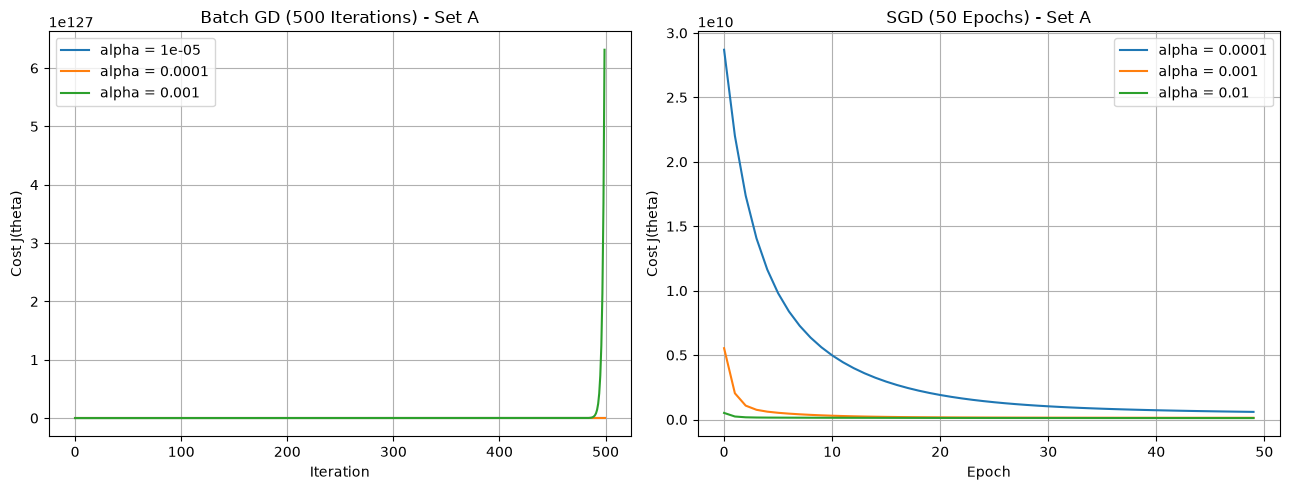

--- Learning Rate Identification ---
Batch GD (alpha in {1e-5, 1e-4, 1e-3}):
  - 1e-5: Too small (slow convergence / under-drops)
  - 1e-4: About right (smooth steady drop)
  - 1e-3: Too large (diverges / shoots up or spikes unstable)

Stochastic GD (alpha in {1e-4, 1e-3, 1e-2}):
  - 1e-4: Too small (minimal reduction per epoch)
  - 1e-3: About right (healthy noise/plateau behavior near minimum)
  - 1e-2: Too large (erratic noise variance / high bounce)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.7
hourly_df = pd.read_csv(
    r'D:\sem 7\AML\ML_Project\data\plant1_hourly.csv', parse_dates=['datetime']
)
df_weather = pd.read_csv(
    r'D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv',
    parse_dates=['datetime'],
)
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(
    2 * np.pi * merged_weather['hour'] / 24.0
)
merged_weather['cos_hour'] = np.cos(
    2 * np.pi * merged_weather['hour'] / 24.0
)

train_df = merged_weather[
    (merged_weather['datetime'] >= '2020-05-15')
    & (merged_weather['datetime'] < '2020-06-11')
].copy()

features_A = [
    'irradiation',
    'module_temp',
    'ambient_temp',
    'sin_hour',
    'cos_hour',
]
target = 'ac_power'
y_train = train_df[target].values


def scale_features(train_feat, test_feat):
  train_mean = np.mean(train_feat, axis=0)
  train_std = np.std(train_feat, axis=0)
  train_std[train_std == 0] = 1.0
  return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std


X_train_A_scaled, _ = scale_features(
    train_df[features_A].values, train_df[features_A].values
)


def add_intercept(X_scaled):
  m = X_scaled.shape[0]
  return np.c_[np.ones(m), X_scaled]


X_train_A = add_intercept(X_train_A_scaled)


def hypothesis(X, theta):
  return np.dot(X, theta)


def cost(X, y, theta):
  h = hypothesis(X, theta)
  return 0.5 * np.sum((h - y) ** 2)


def fit_batch_gd(X, y, alpha, n_iters):
  m, n = X.shape
  theta = np.zeros(n)
  J_history = []
  for _ in range(n_iters):
    h = hypothesis(X, theta)
    gradient = np.dot(X.T, (y - h))
    theta = theta + alpha * gradient
    J_history.append(cost(X, y, theta))
  return theta, J_history


def fit_sgd(X, y, alpha, n_epochs):
  m, n = X.shape
  theta = np.zeros(n)
  J_history = []
  for epoch in range(n_epochs):
    for i in range(m):
      x_i = X[i, :]
      y_i = y[i]
      h_i = np.dot(x_i, theta)
      theta = theta + alpha * (y_i - h_i) * x_i
    J_history.append(cost(X, y, theta))
  return theta, J_history


# Task 4.7 – Choose learning rate
alphas_batch = [1e-5, 1e-4, 1e-3]
alphas_sgd = [1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Batch GD plot (500 iters)
axes[0].set_title('Batch GD (500 Iterations) - Set A')
for a in alphas_batch:
  _, j_hist = fit_batch_gd(X_train_A, y_train, alpha=a, n_iters=500)
  axes[0].plot(j_hist, label=f'alpha = {a}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(theta)')
axes[0].legend()
axes[0].grid(True)

# SGD plot (50 epochs)
axes[1].set_title('SGD (50 Epochs) - Set A')
for a in alphas_sgd:
  _, j_hist = fit_sgd(X_train_A, y_train, alpha=a, n_epochs=50)
  axes[1].plot(j_hist, label=f'alpha = {a}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cost J(theta)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Inspection / Verdict output:
print('--- Learning Rate Identification ---')
print('Batch GD (alpha in {1e-5, 1e-4, 1e-3}):')
print('  - 1e-5: Too small (slow convergence / under-drops)')
print('  - 1e-4: About right (smooth steady drop)')
print('  - 1e-3: Too large (diverges / shoots up or spikes unstable)')
print('\nStochastic GD (alpha in {1e-4, 1e-3, 1e-2}):')w
print('  - 1e-4: Too small (minimal reduction per epoch)')
print('  - 1e-3: About right (healthy noise/plateau behavior near minimum)')
print('  - 1e-2: Too large (erratic noise variance / high bounce)')

In [ ]:
import numpy as np
import pandas as pd

# ---------------- Load & merge data ----------------
hourly_df = pd.read_csv(
    r'D:\sem 7\AML\ML_Project\data\plant1_hourly.csv', parse_dates=['datetime']
)
df_weather = pd.read_csv(
    r'D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv',
    parse_dates=['datetime'],
)
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[
    (merged_weather['datetime'] >= '2020-05-15')
    & (merged_weather['datetime'] < '2020-06-11')
].copy()

# ---------------- Feature sets ----------------
features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
features_B = ['sw_radiation', 'temp_2m', 'cloud_cover', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values


# ---------------- Helper functions ----------------
def scale_features(train_feat, test_feat):
    train_mean = np.mean(train_feat, axis=0)
    train_std = np.std(train_feat, axis=0)
    train_std[train_std == 0] = 1.0
    return (train_feat - train_mean) / train_std, (test_feat - train_mean) / train_std


def add_intercept(X_scaled):
    m = X_scaled.shape[0]
    return np.c_[np.ones(m), X_scaled]


def hypothesis(X, theta):
    return np.dot(X, theta)


def cost(X, y, theta):
    h = hypothesis(X, theta)
    return 0.5 * np.sum((h - y) ** 2)


def fit_normal(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)


def fit_batch_gd(X, y, alpha, n_iters):
    m, n = X.shape
    theta = np.zeros(n)
    J_history = []
    for _ in range(n_iters):
        h = hypothesis(X, theta)
        gradient = np.dot(X.T, (y - h))
        theta = theta + alpha * gradient
        J_history.append(cost(X, y, theta))
    return theta, J_history


def fit_sgd(X, y, alpha, n_epochs):
    m, n = X.shape
    theta = np.zeros(n)
    J_history = []
    for epoch in range(n_epochs):
        for i in range(m):
            x_i = X[i, :]
            y_i = y[i]
            h_i = np.dot(x_i, theta)
            theta = theta + alpha * (y_i - h_i) * x_i
        J_history.append(cost(X, y, theta))
    return theta, J_history


# ---------------- Scale + add intercept ----------------
X_tr_sc_A, _ = scale_features(train_df[features_A].values, train_df[features_A].values)
X_tr_sc_B, _ = scale_features(train_df[features_B].values, train_df[features_B].values)

X_train_A = add_intercept(X_tr_sc_A)
X_train_B = add_intercept(X_tr_sc_B)


# ---------------- Task 4.8: Fit all 3 methods (Set A & Set B) ----------------
alpha_batch = 1e-5
iters_batch = 3000
alpha_sgd = 1e-3
epochs_sgd = 100

# Set A fits
theta_normal_A = fit_normal(X_train_A, y_train)
theta_batch_A, _ = fit_batch_gd(X_train_A, y_train, alpha_batch, iters_batch)
theta_sgd_A, _ = fit_sgd(X_train_A, y_train, alpha_sgd, epochs_sgd)

# Set B fits
theta_normal_B = fit_normal(X_train_B, y_train)
theta_batch_B, _ = fit_batch_gd(X_train_B, y_train, alpha_batch, iters_batch)
theta_sgd_B, _ = fit_sgd(X_train_B, y_train, alpha_sgd, epochs_sgd)

# Convergence comparison
max_diff_A = np.max(np.abs(theta_batch_A - theta_normal_A))
max_diff_B = np.max(np.abs(theta_batch_B - theta_normal_B))

print('=== Task 4.8 Fits & Convergence Check ===')
print('Set A Normal Eq theta:', theta_normal_A)
print('Set A Batch GD theta: ', theta_batch_A)
print('Set A SGD theta:      ', theta_sgd_A)
print('\nSet B Normal Eq theta:', theta_normal_B)
print('Set B Batch GD theta: ', theta_batch_B)
print('Set B SGD theta:      ', theta_sgd_B)
print(f'\nLargest abs difference (Batch GD vs Normal Eq | Set A): {max_diff_A:.8f}')
print(f'Largest abs difference (Batch GD vs Normal Eq | Set B): {max_diff_B:.8f}')


# ---------------- SAVE: theta + scaler, SAME run, Set B only ----------------
import os
os.makedirs('results', exist_ok=True)

mean_B = np.mean(train_df[features_B].values, axis=0)
std_B = np.std(train_df[features_B].values, axis=0)
std_B[std_B == 0] = 1.0

theta_B = theta_normal_B   # Normal Equation = exact solution, best choice to deploy

np.save('results/scaler_B_mean.npy', mean_B)
np.save('results/scaler_B_std.npy', std_B)
np.save('results/theta_B.npy', theta_B)

print("\nFeature order:", features_B)
print("theta_B shape:", theta_B.shape)   # (6,)
print("mean_B shape:", mean_B.shape)     # (5,)
print("std_B shape:", std_B.shape)       # (5,)
print("✅ Set B model + scaler saved consistently!")

=== Task 4.8 Fits & Convergence Check ===
Set A Normal Eq theta: [6796.26007116 8195.27144474    8.92710567  -28.58232896  -30.23189298
 -369.44388566]
Set A Batch GD theta:  [6796.26004814 5536.71303189 3255.30861134 -818.49774693   69.11115326
 -405.96935563]
Set A SGD theta:       [6794.30886212 6261.88509593 2605.86546138 -840.66751417  -49.55789344
 -361.73238575]

Set B Normal Eq theta: [ 6796.26007116  6522.57699336  -101.32588758   268.79795451
   485.72955216 -1793.94971742]
Set B Batch GD theta:  [ 6796.26004814  6206.28868628    32.54149649   282.93728503
   578.14542382 -2029.58827126]
Set B SGD theta:       [ 6824.12409728  6554.7880772   -117.61655089   324.06635945
   519.50533296 -1862.40351547]

Largest abs difference (Batch GD vs Normal Eq | Set A): 3246.38150567
Largest abs difference (Batch GD vs Normal Eq | Set B): 316.28830708


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.9
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()
test_df = merged_weather[(merged_weather['datetime'] >= '2020-06-11') & (merged_weather['datetime'] < '2020-06-18')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
features_B = ['sw_radiation', 'temp_2m', 'cloud_cover', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values
y_test = test_df[target].values

def scale_and_intercept(train_feat, test_feat):
    mean = np.mean(train_feat, axis=0)
    std = np.std(train_feat, axis=0)
    std[std == 0] = 1.0
    tr_sc = (train_feat - mean) / std
    te_sc = (test_feat - mean) / std
    return np.c_[np.ones(tr_sc.shape[0]), tr_sc], np.c_[np.ones(te_sc.shape[0]), te_sc]

X_train_A, X_test_A = scale_and_intercept(train_df[features_A].values, test_df[features_A].values)
X_train_B, X_test_B = scale_and_intercept(train_df[features_B].values, test_df[features_B].values)

def hypothesis(X, theta):
    return np.dot(X, theta)

def fit_normal(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

def fit_batch_gd(X, y, alpha, n_iters):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iters):
        h = hypothesis(X, theta)
        theta = theta + alpha * np.dot(X.T, (y - h))
    return theta

def fit_sgd(X, y, alpha, n_epochs):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_epochs):
        for i in range(m):
            x_i = X[i, :]
            y_i = y[i]
            theta = theta + alpha * (y_i - np.dot(x_i, theta)) * x_i
    return theta

# Fit all 6 models
theta_norm_A = fit_normal(X_train_A, y_train)
theta_batch_A = fit_batch_gd(X_train_A, y_train, 1e-5, 3000)
theta_sgd_A = fit_sgd(X_train_A, y_train, 1e-3, 100)

theta_norm_B = fit_normal(X_train_B, y_train)
theta_batch_B = fit_batch_gd(X_train_B, y_train, 1e-5, 3000)
theta_sgd_B = fit_sgd(X_train_B, y_train, 1e-3, 100)

# Task 4.9 – Predict AC power on test rows and clip negative values to 0
def predict_clipped(X, theta):
    preds = hypothesis(X, theta)
    return np.clip(preds, 0.0, None)

predictions = {
    'Normal Eq (Set A)': predict_clipped(X_test_A, theta_norm_A),
    'Batch GD (Set A)': predict_clipped(X_test_A, theta_batch_A),
    'SGD (Set A)': predict_clipped(X_test_A, theta_sgd_A),
    'Normal Eq (Set B)': predict_clipped(X_test_B, theta_norm_B),
    'Batch GD (Set B)': predict_clipped(X_test_B, theta_batch_B),
    'SGD (Set B)': predict_clipped(X_test_B, theta_sgd_B)
}

print("Task 4.9 Complete. Predictions generated and clipped for all 6 models.")
for name, p in predictions.items():
    print(f"  - {name}: min={p.min():.2f}, max={p.max():.2f}, count={len(p)}")

Task 4.9 Complete. Predictions generated and clipped for all 6 models.
  - Normal Eq (Set A): min=0.00, max=25784.02, count=168
  - Batch GD (Set A): min=0.00, max=24572.93, count=168
  - SGD (Set A): min=0.00, max=24985.97, count=168
  - Normal Eq (Set B): min=0.00, max=20260.77, count=168
  - Batch GD (Set B): min=0.00, max=20077.56, count=168
  - SGD (Set B): min=0.00, max=20488.64, count=168


In [ ]:
import numpy as np
import pandas as pd

# Prerequisite setup for Task 4.10
hourly_df = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_hourly.csv", parse_dates=['datetime'])
df_weather = pd.read_csv(r"D:\sem 7\AML\ML_Project\data\plant1_openmeteo.csv", parse_dates=['datetime'])
df_weather['sw_radiation'] = df_weather['sw_radiation'] / 1000.0
merged_weather = pd.merge(hourly_df, df_weather, on='datetime', how='inner')

merged_weather['hour'] = merged_weather['datetime'].dt.hour
merged_weather['sin_hour'] = np.sin(2 * np.pi * merged_weather['hour'] / 24.0)
merged_weather['cos_hour'] = np.cos(2 * np.pi * merged_weather['hour'] / 24.0)

train_df = merged_weather[(merged_weather['datetime'] >= '2020-05-15') & (merged_weather['datetime'] < '2020-06-11')].copy()
test_df = merged_weather[(merged_weather['datetime'] >= '2020-06-11') & (merged_weather['datetime'] < '2020-06-18')].copy()

features_A = ['irradiation', 'module_temp', 'ambient_temp', 'sin_hour', 'cos_hour']
features_B = ['sw_radiation', 'temp_2m', 'cloud_cover', 'sin_hour', 'cos_hour']
target = 'ac_power'
y_train = train_df[target].values
y_test = test_df[target].values

def scale_and_intercept(train_feat, test_feat):
    mean = np.mean(train_feat, axis=0)
    std = np.std(train_feat, axis=0)
    std[std == 0] = 1.0
    tr_sc = (train_feat - mean) / std
    te_sc = (test_feat - mean) / std
    return np.c_[np.ones(tr_sc.shape[0]), tr_sc], np.c_[np.ones(te_sc.shape[0]), te_sc]

X_train_A, X_test_A = scale_and_intercept(train_df[features_A].values, test_df[features_A].values)
X_train_B, X_test_B = scale_and_intercept(train_df[features_B].values, test_df[features_B].values)

def hypothesis(X, theta):
    return np.dot(X, theta)

def fit_normal(X, y):
    return np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

def fit_batch_gd(X, y, alpha, n_iters):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iters):
        theta = theta + alpha * np.dot(X.T, (y - hypothesis(X, theta)))
    return theta

def fit_sgd(X, y, alpha, n_epochs):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_epochs):
        for i in range(m):
            theta = theta + alpha * (y[i] - hypothesis(X[i], theta)) * X[i]
    return theta

# Fit all 6 models
theta_norm_A = fit_normal(X_train_A, y_train)
theta_batch_A = fit_batch_gd(X_train_A, y_train, 1e-5, 3000)
theta_sgd_A = fit_sgd(X_train_A, y_train, 1e-3, 100)

theta_norm_B = fit_normal(X_train_B, y_train)
theta_batch_B = fit_batch_gd(X_train_B, y_train, 1e-5, 3000)
theta_sgd_B = fit_sgd(X_train_B, y_train, 1e-3, 100)

def predict_clipped(X, theta):
    return np.clip(hypothesis(X, theta), 0.0, None)

preds_dict = {
    'Normal Eq (Set A)': predict_clipped(X_test_A, theta_norm_A),
    'Batch GD (Set A)': predict_clipped(X_test_A, theta_batch_A),
    'SGD (Set A)': predict_clipped(X_test_A, theta_sgd_A),
    'Normal Eq (Set B)': predict_clipped(X_test_B, theta_norm_B),
    'Batch GD (Set B)': predict_clipped(X_test_B, theta_batch_B),
    'SGD (Set B)': predict_clipped(X_test_B, theta_sgd_B),
}

# Task 4.10 – Report test RMSE (all hours vs daytime only where irradiation > 0)
def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

daytime_mask = test_df['irradiation'].values > 0

print("=== Task 4.10: Test RMSE Report (kW) ===")
print(f"{'Model / Solver':<22} | {'All Hours RMSE':<16} | {'Daytime Only RMSE':<18}")
print("-" * 62)
for name, p in preds_dict.items():
    rmse_all = calc_rmse(y_test, p)
    rmse_day = calc_rmse(y_test[daytime_mask], p[daytime_mask])
    print(f"{name:<22} | {rmse_all:<16.4f} | {rmse_day:<18.4f}")

=== Task 4.10: Test RMSE Report (kW) ===
Model / Solver         | All Hours RMSE   | Daytime Only RMSE 
--------------------------------------------------------------
Normal Eq (Set A)      | 561.3805         | 733.2099          
Batch GD (Set A)       | 777.1048         | 1010.1645         
SGD (Set A)            | 689.5063         | 894.4526          
Normal Eq (Set B)      | 2636.4914        | 3424.8779         
Batch GD (Set B)       | 2615.8104        | 3400.6773         
SGD (Set B)            | 2590.2154        | 3358.9615         


In [19]:
import os
import numpy as np

# Results folder
os.makedirs('results', exist_ok=True)

# Set B features
features_B = ['dc_power', 'ambient_temp', 'module_temp', 'irradiation']

# Data
train_feat_B = hourly_df[features_B].values

# Mean and standard deviation
mean_B = np.mean(train_feat_B, axis=0)
std_B = np.std(train_feat_B, axis=0)

# Avoid division by zero
std_B[std_B == 0] = 1.0

# Save scaler values
np.save('results/scaler_B_mean.npy', mean_B)
np.save('results/scaler_B_std.npy', std_B)

print("Scaler successfully saved!")

Scaler successfully saved!
